In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_train = pd.read_excel(r'Data_Train.xlsx')
df_train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
df_train['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [6]:
df_train.shape

(10683, 11)

In [7]:
df_train['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
df_train.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [6]:
df_train[df_train['Route'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [7]:
pd.set_option('display.max_columns',None)

In [8]:
df_train['dep_hour'] = pd.to_datetime(df_train['Dep_Time']).dt.hour
df_train['dep_min'] = pd.to_datetime(df_train['Dep_Time']).dt.minute
df_train.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\2636056931.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train['dep_hour'] = pd.to_datetime(df_train['Dep_Time']).dt.hour
C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\2636056931.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train['dep_min'] = pd.to_datetime(df_train['Dep_Time']).dt.minute


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,dep_hour,dep_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,22,20
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,50
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,18,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,16,50


In [9]:
df_train.drop(['Dep_Time'],axis = 1, inplace = True)

In [10]:
df_train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,dep_hour,dep_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,22,20
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,5,50
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,18,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,16,50


In [11]:
df_train['Arrival_hour'] = pd.to_datetime(df_train['Arrival_Time']).dt.hour
df_train['Arrival_min'] = pd.to_datetime(df_train['Arrival_Time']).dt.minute
df_train.drop(['Arrival_Time'], axis = 1, inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\1369190553.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train['Arrival_hour'] = pd.to_datetime(df_train['Arrival_Time']).dt.hour
C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\1369190553.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train['Arrival_min'] = pd.to_datetime(df_train['Arrival_Time']).dt.minute


In [12]:
df_train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,dep_hour,dep_min,Arrival_hour,Arrival_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,22,20,1,10
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,50,13,15
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,25,4,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,18,5,23,30
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,16,50,21,35


In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Duration         10683 non-null  object
 6   Total_Stops      10682 non-null  object
 7   Additional_Info  10683 non-null  object
 8   Price            10683 non-null  int64 
 9   dep_hour         10683 non-null  int32 
 10  dep_min          10683 non-null  int32 
 11  Arrival_hour     10683 non-null  int32 
 12  Arrival_min      10683 non-null  int32 
dtypes: int32(4), int64(1), object(8)
memory usage: 918.2+ KB


In [14]:
df_train['Journey_day'] = pd.to_datetime(df_train['Date_of_Journey'],format = "%d/%m/%Y").dt.day
df_train['Journey_month'] = pd.to_datetime(df_train['Date_of_Journey'],format = "%d/%m/%Y").dt.month
df_train['Journey_Year'] = pd.to_datetime(df_train['Date_of_Journey'],format = "%d/%m/%Y").dt.year
df_train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,dep_hour,dep_min,Arrival_hour,Arrival_min,Journey_day,Journey_month,Journey_Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,22,20,1,10,24,3,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,50,13,15,1,5,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,25,4,25,9,6,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,18,5,23,30,12,5,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,16,50,21,35,1,3,2019


In [15]:
df_train.drop(['Date_of_Journey'], axis = 1, inplace = True)

In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Route            10682 non-null  object
 4   Duration         10683 non-null  object
 5   Total_Stops      10682 non-null  object
 6   Additional_Info  10683 non-null  object
 7   Price            10683 non-null  int64 
 8   dep_hour         10683 non-null  int32 
 9   dep_min          10683 non-null  int32 
 10  Arrival_hour     10683 non-null  int32 
 11  Arrival_min      10683 non-null  int32 
 12  Journey_day      10683 non-null  int32 
 13  Journey_month    10683 non-null  int32 
 14  Journey_Year     10683 non-null  int32 
dtypes: int32(7), int64(1), object(7)
memory usage: 959.9+ KB


In [17]:
df_train['dur_hour'] = df_train['Duration'].str.split(' ').str[0].str.split('h').str[0]

In [18]:
df_train[df_train['Duration']=='5m']

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,dep_hour,dep_min,Arrival_hour,Arrival_min,Journey_day,Journey_month,Journey_Year,dur_hour
6474,Air India,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,5m,2 stops,No info,17327,16,50,16,55,6,3,2019,5m


In [19]:
df_train.drop(6474,axis = 0, inplace = True)
df_train.drop(2660, axis = 0, inplace = True)

In [20]:
df_train['dur_hour'] = df_train['dur_hour'].astype(int)

In [21]:
df_train['dur_min'] = df_train['Duration'].str.split(' ').str[1].str.split('m').str[0]

In [22]:
df_train['dur_min'] = df_train['dur_min'].fillna(0)

In [23]:
df_train.sample(1)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,dep_hour,dep_min,Arrival_hour,Arrival_min,Journey_day,Journey_month,Journey_Year,dur_hour,dur_min
8589,Air India,Delhi,Cochin,DEL → COK,3h,non-stop,No info,6934,14,10,17,10,24,5,2019,3,0


In [24]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10681 entries, 0 to 10682
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10681 non-null  object
 1   Source           10681 non-null  object
 2   Destination      10681 non-null  object
 3   Route            10680 non-null  object
 4   Duration         10681 non-null  object
 5   Total_Stops      10680 non-null  object
 6   Additional_Info  10681 non-null  object
 7   Price            10681 non-null  int64 
 8   dep_hour         10681 non-null  int32 
 9   dep_min          10681 non-null  int32 
 10  Arrival_hour     10681 non-null  int32 
 11  Arrival_min      10681 non-null  int32 
 12  Journey_day      10681 non-null  int32 
 13  Journey_month    10681 non-null  int32 
 14  Journey_Year     10681 non-null  int32 
 15  dur_hour         10681 non-null  int32 
 16  dur_min          10681 non-null  object
dtypes: int32(8), int64(1), object(8)
mem

In [25]:
df_train.drop(['Duration'],axis = 1, inplace = True)

In [26]:
df_train.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,dep_hour,dep_min,Arrival_hour,Arrival_min,Journey_day,Journey_month,Journey_Year,dur_hour,dur_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,22,20,1,10,24,3,2019,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,5,50,13,15,1,5,2019,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,25,4,25,9,6,2019,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,18,5,23,30,12,5,2019,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,16,50,21,35,1,3,2019,4,45


In [27]:
df_train['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1518
3 stops       45
4 stops        1
Name: count, dtype: int64

In [28]:
df_train.isnull().sum()

Airline            0
Source             0
Destination        0
Route              1
Total_Stops        1
Additional_Info    0
Price              0
dep_hour           0
dep_min            0
Arrival_hour       0
Arrival_min        0
Journey_day        0
Journey_month      0
Journey_Year       0
dur_hour           0
dur_min            0
dtype: int64

In [29]:
df_train['Total_Stops'] = df_train['Total_Stops'].fillna(1)

In [30]:
df_train['Total_Stops'] = df_train['Total_Stops'].replace({'1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4, 'non-stop': 0})

C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\2603691456.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['Total_Stops'] = df_train['Total_Stops'].replace({'1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4, 'non-stop': 0})


In [31]:
df_train.drop(['Route'], axis = 1, inplace = True)

In [32]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10681 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10681 non-null  object
 1   Source           10681 non-null  object
 2   Destination      10681 non-null  object
 3   Total_Stops      10681 non-null  int64 
 4   Additional_Info  10681 non-null  object
 5   Price            10681 non-null  int64 
 6   dep_hour         10681 non-null  int32 
 7   dep_min          10681 non-null  int32 
 8   Arrival_hour     10681 non-null  int32 
 9   Arrival_min      10681 non-null  int32 
 10  Journey_day      10681 non-null  int32 
 11  Journey_month    10681 non-null  int32 
 12  Journey_Year     10681 non-null  int32 
 13  dur_hour         10681 non-null  int32 
 14  dur_min          10681 non-null  object
dtypes: int32(8), int64(2), object(5)
memory usage: 1001.3+ KB


In [33]:
df_train.head(3)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,dep_hour,dep_min,Arrival_hour,Arrival_min,Journey_day,Journey_month,Journey_Year,dur_hour,dur_min
0,IndiGo,Banglore,New Delhi,0,No info,3897,22,20,1,10,24,3,2019,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,5,50,13,15,1,5,2019,7,25
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,25,4,25,9,6,2019,19,0


In [34]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [35]:
df_train['Airline'] = label.fit_transform(df_train['Airline'])
df_train['Source'] = label.fit_transform(df_train['Source'])
df_train['Destination'] = label.fit_transform(df_train['Destination'])
df_train['Additional_Info'] = label.fit_transform(df_train['Additional_Info'])

In [36]:
df_train.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,dep_hour,dep_min,Arrival_hour,Arrival_min,Journey_day,Journey_month,Journey_Year,dur_hour,dur_min
0,3,0,5,0,8,3897,22,20,1,10,24,3,2019,2,50
1,1,3,0,2,8,7662,5,50,13,15,1,5,2019,7,25
2,4,2,1,2,8,13882,9,25,4,25,9,6,2019,19,0
3,3,3,0,1,8,6218,18,5,23,30,12,5,2019,5,25
4,3,0,5,1,8,13302,16,50,21,35,1,3,2019,4,45


In [37]:
df_test = pd.read_excel(r'Test_set.xlsx')
df_test.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included


In [38]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          2671 non-null   object
 1   Date_of_Journey  2671 non-null   object
 2   Source           2671 non-null   object
 3   Destination      2671 non-null   object
 4   Route            2671 non-null   object
 5   Dep_Time         2671 non-null   object
 6   Arrival_Time     2671 non-null   object
 7   Duration         2671 non-null   object
 8   Total_Stops      2671 non-null   object
 9   Additional_Info  2671 non-null   object
dtypes: object(10)
memory usage: 208.8+ KB


In [39]:
df_test.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64

In [40]:

df_test[df_test['Duration']=='5m']
df_test.drop(2660, axis = 0, inplace = True)

In [41]:



df_test['Arrival_hour'] = pd.to_datetime(df_test['Arrival_Time']).dt.hour
df_test['Arrival_min'] = pd.to_datetime(df_test['Arrival_Time']).dt.minute
df_test.drop(['Arrival_Time'], axis = 1, inplace = True)

df_test['Journey_day'] = pd.to_datetime(df_test['Date_of_Journey'],format = "%d/%m/%Y").dt.day
df_test['Journey_month'] = pd.to_datetime(df_test['Date_of_Journey'],format = "%d/%m/%Y").dt.month
df_test['Journey_Year'] = pd.to_datetime(df_test['Date_of_Journey'],format = "%d/%m/%Y").dt.year
df_test.drop(['Date_of_Journey'], axis = 1, inplace = True)

df_test['dur_hour'] = df_test['Duration'].str.split(' ').str[0].str.split('h').str[0]
df_test['dur_hour'] = df_test['dur_hour'].astype(int)
df_test.drop(['Duration'],axis = 1, inplace = True)

df_test['Dep_hour'] = pd.to_datetime(df_test['Dep_Time']).dt.hour
df_test['Dep_min'] = pd.to_datetime(df_test['Dep_Time']).dt.minute
df_test['Dep_hour'] = df_test['Dep_hour'].astype(int)
df_test['Dep_min'] = df_test['Dep_min'].astype(int)
df_test.drop(['Dep_Time'],axis = 1, inplace = True)

df_test['Total_Stops'] = df_test['Total_Stops'].replace({'1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4, 'non-stop': 0})
df_test.drop(['Route'], axis = 1, inplace = True)

df_test['Airline'] = label.fit_transform(df_test['Airline'])
df_test['Source'] = label.fit_transform(df_test['Source'])
df_test['Destination'] = label.fit_transform(df_test['Destination'])
df_test['Additional_Info'] = label.fit_transform(df_test['Additional_Info'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\571241680.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test['Arrival_hour'] = pd.to_datetime(df_test['Arrival_Time']).dt.hour
C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\571241680.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test['Arrival_min'] = pd.to_datetime(df_test['Arrival_Time']).dt.minute
C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\571241680.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test['Dep_hour'] = pd.to_datetime(df_test['Dep_Time']).dt.hour
C:\Users\DELL\AppData\Local\Tem

In [90]:
df_test.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Arrival_hour,Arrival_min,Journey_day,Journey_month,Journey_Year,dur_hour,Dep_hour,Dep_min
0,4,2,1,1,5,4,25,6,6,2019,10,17,30
1,3,3,0,1,5,10,20,12,5,2019,4,6,20


In [92]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2670 entries, 0 to 2670
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          2670 non-null   int32
 1   Source           2670 non-null   int32
 2   Destination      2670 non-null   int32
 3   Total_Stops      2670 non-null   int64
 4   Additional_Info  2670 non-null   int32
 5   Arrival_hour     2670 non-null   int32
 6   Arrival_min      2670 non-null   int32
 7   Journey_day      2670 non-null   int32
 8   Journey_month    2670 non-null   int32
 9   Journey_Year     2670 non-null   int32
 10  dur_hour         2670 non-null   int32
 11  Dep_hour         2670 non-null   int32
 12  Dep_min          2670 non-null   int32
dtypes: int32(12), int64(1)
memory usage: 166.9 KB


## Feature Selection

finding out the best feature which will contribute and have good relation with target variable 

1. Heatmap
2. Feature_importance
3. SelectKBest

In [98]:
df_train.shape

(10681, 15)

In [110]:
X = df_train.drop(['Price'],axis = 1)

In [112]:
X.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,dep_hour,dep_min,Arrival_hour,Arrival_min,Journey_day,Journey_month,Journey_Year,dur_hour,dur_min
0,3,0,5,0,8,22,20,1,10,24,3,2019,2,50
1,1,3,0,2,8,5,50,13,15,1,5,2019,7,25
2,4,2,1,2,8,9,25,4,25,9,6,2019,19,0
3,3,3,0,1,8,18,5,23,30,12,5,2019,5,25
4,3,0,5,1,8,16,50,21,35,1,3,2019,4,45


In [114]:
y = df_train['Price']
y.head()

0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

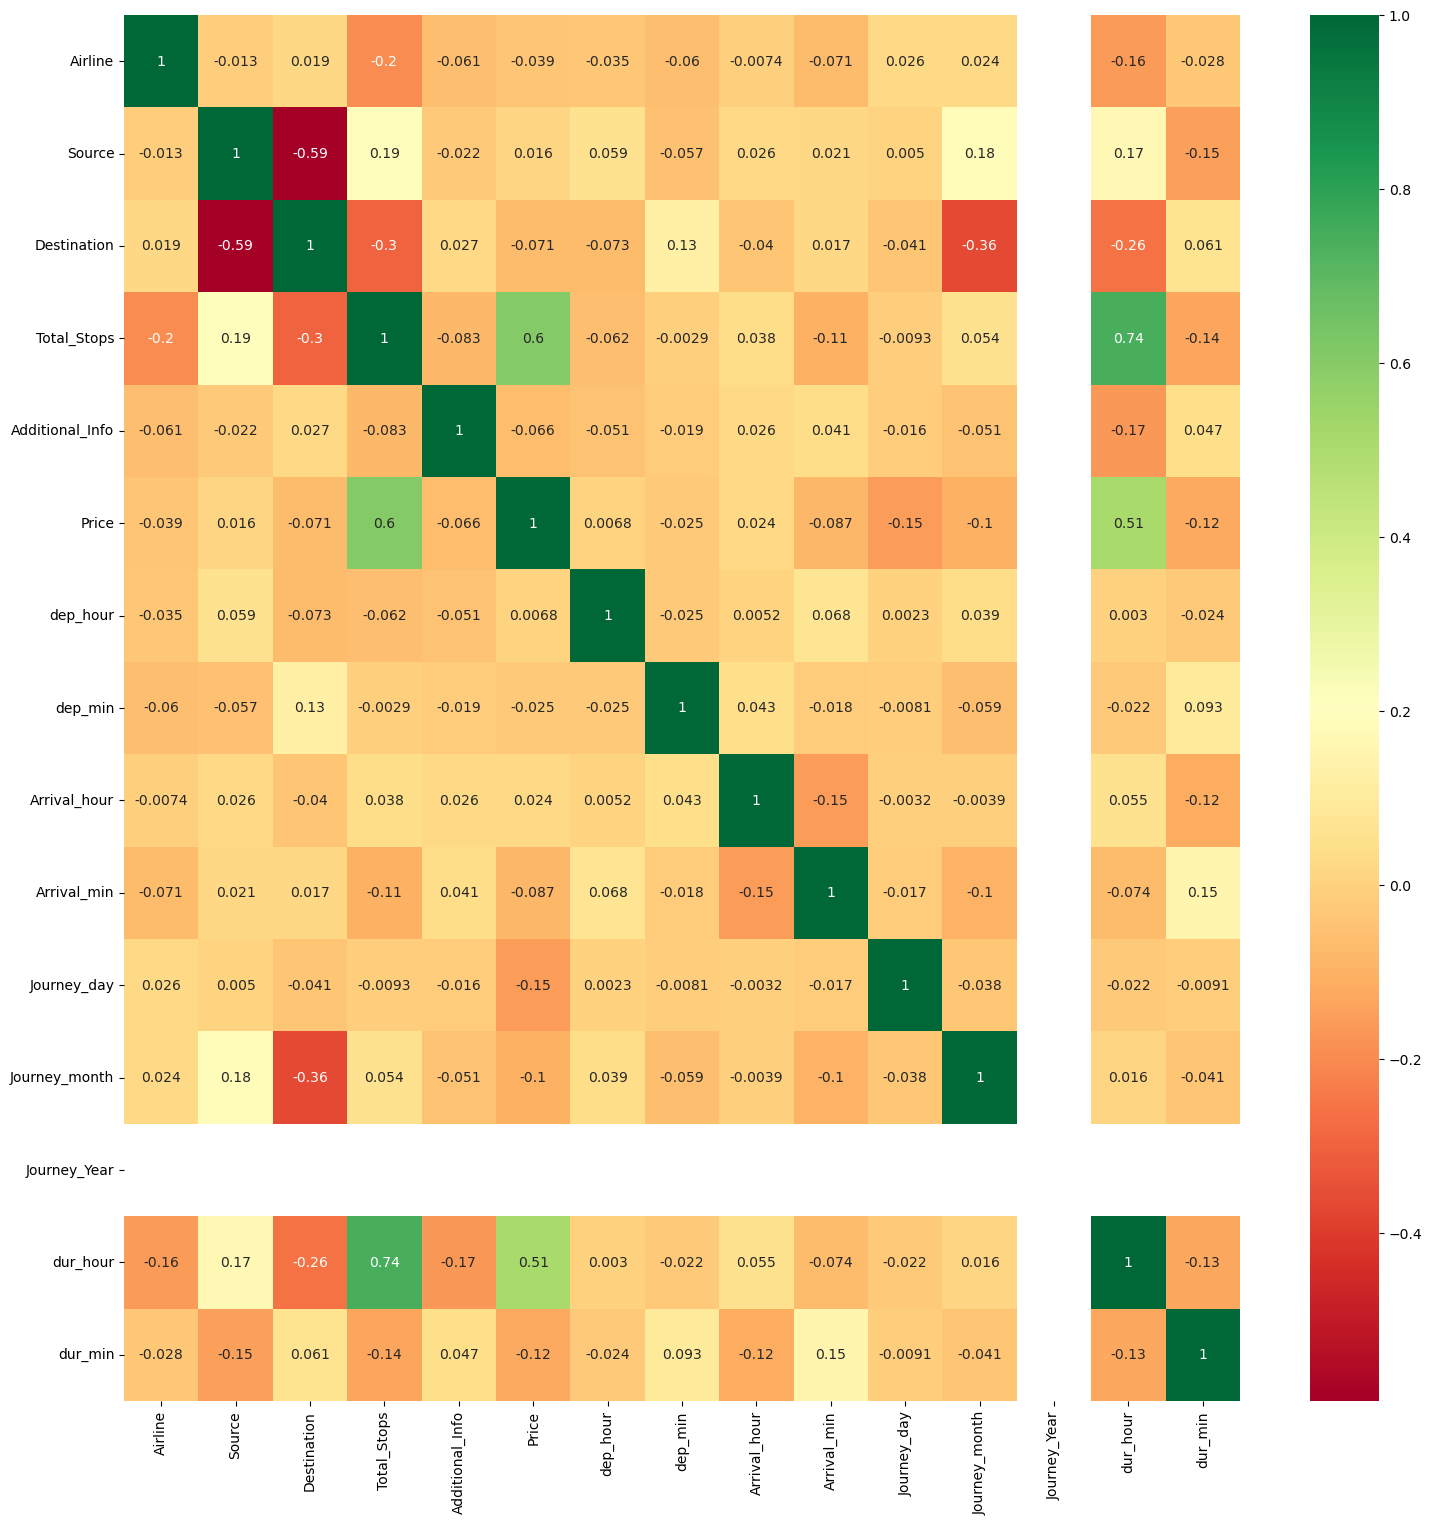

In [118]:
# Finding the correlation between Independent and dependant attributes
plt.figure(figsize = (18,18))
sns.heatmap(df_train.corr(),annot = True, cmap = 'RdYlGn')
plt.show()

In [120]:
# Important feature using ExtraTreeRegressor

from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(X,y)

ExtraTreesRegressor()

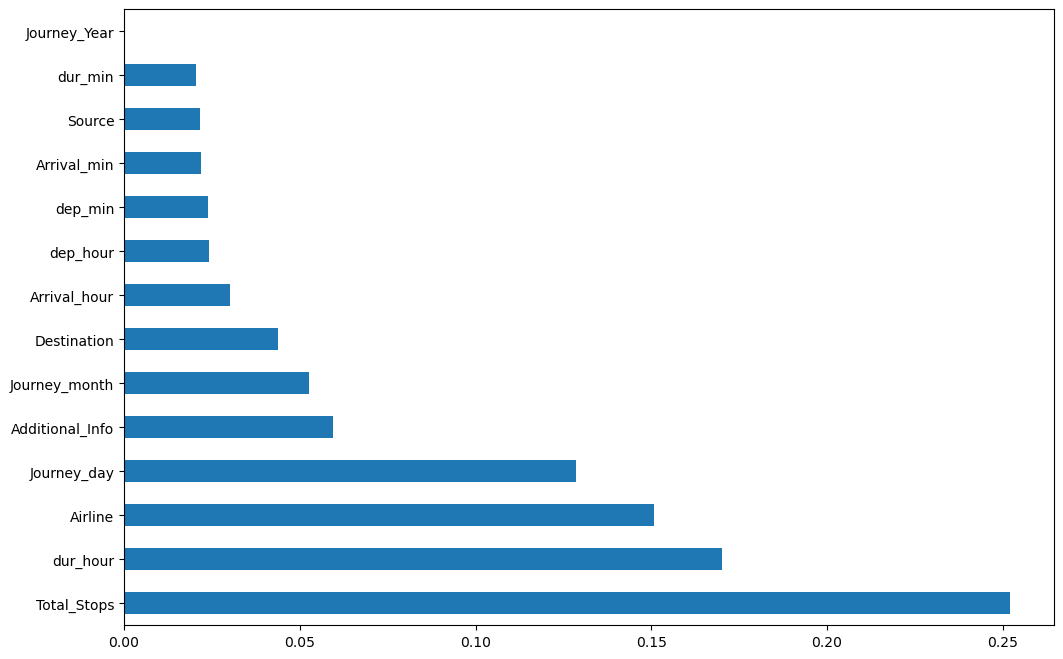

In [124]:
# plot graph of feature importances fo rbetter Visulization

plt.figure(figsize = (12,8))
feat_importances = pd.Series(selection.feature_importances_,index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

In [126]:
# Fitting model on RandomForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [128]:
rfc = RandomForestRegressor()
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [130]:
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)

In [134]:
rfc.score(X_train, y_train)

0.9815758140755557

In [136]:
rfc.score(X_test,y_test)

0.8420121226688032

C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\3453123835.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-y_pred)


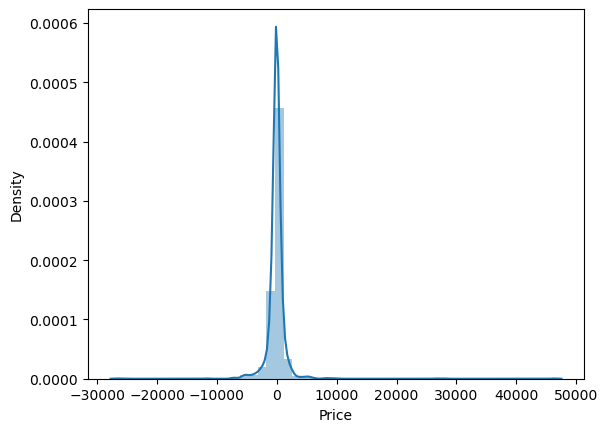

In [138]:
sns.distplot(y_test-y_pred)
plt.show()

In [146]:
from sklearn import metrics
from sklearn.metrics import r2_score

In [148]:
r2_score(y_test,y_pred)

0.8420121226688032

## Hypertuning

In [154]:
from sklearn.model_selection import RandomizedSearchCV

In [166]:
# Number of the parameter 
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1200, num = 12)]
#Number of feature to consider at ever split
max_features = ['auto','sqrt']
#Maximum number of levels in tree
max_depth = [ int(x) for x in np.linspace(5,30,num = 6)]
# Maximum number of sample requried
min_samples_split = [2, 5, 10, 15, 100]
# Manimum number of sample requried
min_samples_leaf = [1, 2, 5, 10]

In [168]:
random_grid = {
    'n_estimators' : n_estimators,
    'max_features' : max_features,
    'max_depth' : max_depth,
    'min_samples_split' : min_samples_split,
    'min_samples_leaf' : min_samples_leaf
}

In [170]:
rf_random = RandomizedSearchCV(estimator = rfc, param_distributions = random_grid, scoring = 'neg_mean_squared_error',n_iter  = 10, cv = 5, verbose = 2, n_jobs = 1, random_state = 42)

In [172]:
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   3.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   3.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   3.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   3.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   3.3s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=   5.3s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=   5.7s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimator

C:\Users\DELL\anaconda3\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\DELL\anaconda3\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\DELL\anaconda3\anaconda\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "C:\Users\DELL\anaconda3\anaconda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\DE

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=1,
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              100],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100,
                                                         1200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [174]:
rf_random.best_params_

{'n_estimators': 1000,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 25}

In [176]:
prediction = rf_random.predict(X_test)

C:\Users\DELL\AppData\Local\Temp\ipykernel_12020\375150797.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-prediction)


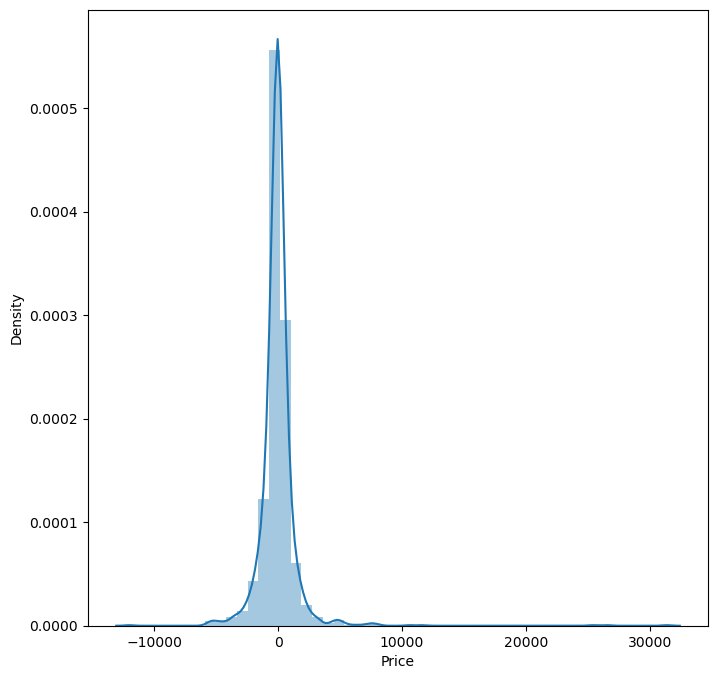

In [178]:
plt.figure(figsize = (8,8))
sns.distplot(y_test-prediction)
plt.show()

In [180]:
r2_score(y_test,prediction)

0.8823744007558201

In [203]:
with open('flight_rfc_new.pkl', 'wb') as file:
    pickle.dump(rf_random, file)


In [205]:
model = open('flight_rfr.pkl','rb')
forests = pickle.load(model)

In [207]:
y_prediction = forest.predict(X_test)

In [211]:
r2_score(y_test,y_prediction)

0.8420121226688032